In [1]:
import os,sys
print(os.getcwd())
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print("Project root directory:", project_root)
sys.path.append(project_root)

/home/zhaolei/meal-rec-ai/preprocess
Project root directory: /home/zhaolei/meal-rec-ai


# 1. User daily nutrition intake

In [2]:
import pandas as pd
from utils.data import root_path
file_food_user = f'{root_path}food_user.csv'
file_food_code= f'{root_path}food_code.csv'
file_nutrition = f'{root_path}food_nutrition.csv'
file_user = f'{root_path}users.csv'
file_pa = f'{root_path}pa.csv'
file_suppl = f'{root_path}supplement.csv'
df_user = pd.read_csv(file_user)
df_user = df_user.drop_duplicates(subset=['user_id', 'years'])
df_food_user = pd.read_csv(file_food_user)
df_food_code=  pd.read_csv(file_food_code)
df_nutrition = pd.read_csv(file_nutrition)
df_pa = pd.read_csv(file_pa)
df_suppl = pd.read_csv(file_suppl)
print(f'user length:{len(df_user)}')
print(f'food_user length:{len(df_food_user)}')
print(f'nutrition length:{len(df_nutrition)}')
df_user = pd.merge(df_user, df_pa, on=['user_id', 'years'], how='left')
df_user = df_user.fillna(0)
df_food_user_with_nutrition = pd.merge(df_food_user, df_nutrition, on=['food_id', 'grams'], how='left')
df_food_user_with_nutrition = pd.merge(df_food_user_with_nutrition, df_user, on=['user_id', 'years'], how='left')
# remove <19 years old, remove diet supplement data
df_food_user_with_nutrition = df_food_user_with_nutrition[df_food_user_with_nutrition['age'] >= 19]
# 创建一个包含 df_suppl 中所有 (SEQN, day, years) 组合的集合
suppl_keys = set(zip(df_suppl['user_id'], df_suppl['day'], df_suppl['years']))
# 筛选 df_food_user_with_nutrition 中不在 df_suppl 中的行
df_food_user_with_nutrition = df_food_user_with_nutrition[~df_food_user_with_nutrition.apply(lambda row: (row['user_id'], row['day'], row['years']) in suppl_keys,axis=1)]
# 按 SEQN（用户标识符）,year, day（天数）分组，然后对营养成分求和
nutrition_grouped = df_food_user_with_nutrition.groupby(['user_id', 'years', 'day', 'age_group', 'gender']).agg({
'grams': 'sum',
'calorie': 'sum',
'protein': 'sum',
'carb': 'sum',
'sugar': 'sum',
'fiber': 'sum',
'saturated_fat': 'sum',
'cholesterol': 'sum',
'folic_acid': 'sum',
'vitamin_b12': 'sum',
'vitamin_c': 'sum',
'vitamin_d': 'sum',
'calcium': 'sum',
'phosphorus': 'sum',
'potassium': 'sum',
'iron': 'sum',
'sodium': 'sum'
}).reset_index()
daily_nutrition_intake_summary = pd.merge(nutrition_grouped, df_user, on=['user_id', 'years', 'gender', 'age_group'],
  how='left')

user length:83388
food_user length:2322627
nutrition length:213569


# 2.Evaluate Healthiness 

In [13]:
# 定义函数应用 evaluate 类
from utils.health_evaluate import evaluate_macro_nutrition,evaluate_micro_nutrition,ismatch_nutrition_by_situation

# 应用 evaluate_nutrition 函数
daily_nutrition_intake_summary[['b_calorie','b_carb','b_fiber','b_protein','b_saturated_fat','b_sugar','b_cholesterol','macro_health_score']] \
        =daily_nutrition_intake_summary.apply(evaluate_macro_nutrition, axis=1)
# 应用 evaluate_nutrition 函数
daily_nutrition_intake_summary[['b_sodium','b_phosphorus','b_potassium','b_iron','b_calcium','b_folic_acid','b_vitamin_c','b_vitamin_d','b_vitamin_b12', 'micro_health_score']] \
    =daily_nutrition_intake_summary.apply(evaluate_micro_nutrition, axis=1)
# 应用 evaluate_nutrition 函数
daily_nutrition_intake_summary['match'] =daily_nutrition_intake_summary.apply(ismatch_nutrition_by_situation, axis=1)
daily_nutrition_intake_summary[daily_nutrition_intake_summary['match']==True]

,user_id,years,day,age_group,gender,grams,calorie,protein,carb,sugar,...,b_iron,b_calcium,b_folic_acid,b_vitamin_c,b_vitamin_d,b_vitamin_b12,micro_health_score,match,total_positive_score,total_negative_score
81,21089,304,1.0,4.0,2.0,2017.28,1723.0,35.61,316.51,214.60,...,True,True,True,True,True,False,7,True,0,0
242,21266,304,2.0,2.0,2.0,1255.85,1885.0,30.51,282.21,190.63,...,True,True,True,True,True,True,9,True,0,0
324,21351,304,2.0,4.0,2.0,2044.35,1793.0,52.31,242.20,111.92,...,True,True,True,True,True,False,8,True,0,0
757,21866,304,1.0,3.0,2.0,2322.63,1904.0,44.09,328.83,176.99,...,True,True,True,True,True,False,7,True,0,0
873,22013,304,1.0,2.0,2.0,1891.16,1665.0,47.22,258.69,171.27,...,True,True,True,True,True,False,8,True,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32952,122423,1720,2.0,5.0,1.0,420.00,1046.0,65.11,64.22,1.50,...,True,True,True,True,True,False,8,True,0,0
33028,122913,1720,2.0,3.0,1.0,135.00,291.0,18.03,31.31,4.18,...,True,True,True,True,True,True,7,True,0,0
33074,123295,1720,1.0,4.0,2.0,30.00,129.0,0.40,1.77,1.41,...,True,True,True,True,True,True,7,True,0,0
33089,123399,1720,1.0,7.0,1.0,80.00,190.0,9.89,25.48,8.21,...,True,True,True,True,True,True,8,True,0,0


In [4]:
daily_nutrition_intake_summary

,user_id,years,day,age_group,gender,grams,calorie,protein,carb,sugar,...,b_phosphorus,b_potassium,b_iron,b_calcium,b_folic_acid,b_vitamin_c,b_vitamin_d,b_vitamin_b12,micro_health_score,match
0,21005,304,1.0,2.0,1.0,2901.11,2984.0,67.17,459.27,258.71,...,True,True,True,True,True,True,True,True,8,False
1,21005,304,2.0,2.0,1.0,1886.91,2211.0,104.66,239.73,140.01,...,True,True,True,True,True,True,True,False,7,False
2,21009,304,1.0,6.0,1.0,6383.11,5606.0,157.72,733.26,499.55,...,True,False,True,True,True,True,True,False,6,False
3,21009,304,2.0,6.0,1.0,2365.08,3475.0,80.13,478.20,231.18,...,True,True,True,True,True,True,True,False,7,False
4,21010,304,1.0,6.0,2.0,3792.40,2171.0,73.38,277.84,149.55,...,True,True,True,True,True,True,True,False,7,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33343,124792,1720,2.0,4.0,1.0,148.75,259.0,10.98,23.50,0.68,...,False,True,True,True,True,True,True,True,7,False
33344,124807,1720,1.0,5.0,1.0,73.83,107.0,11.41,3.62,0.05,...,False,True,True,True,True,True,True,True,7,False
33345,124810,1720,1.0,6.0,2.0,121.50,265.0,19.17,25.39,3.39,...,False,False,True,True,True,True,True,True,7,False
33346,124814,1720,1.0,7.0,1.0,157.50,229.0,20.62,16.63,0.39,...,False,False,True,True,True,True,True,True,7,False


# 3. Health Food Category

## 3.1 DASH Eating Plan
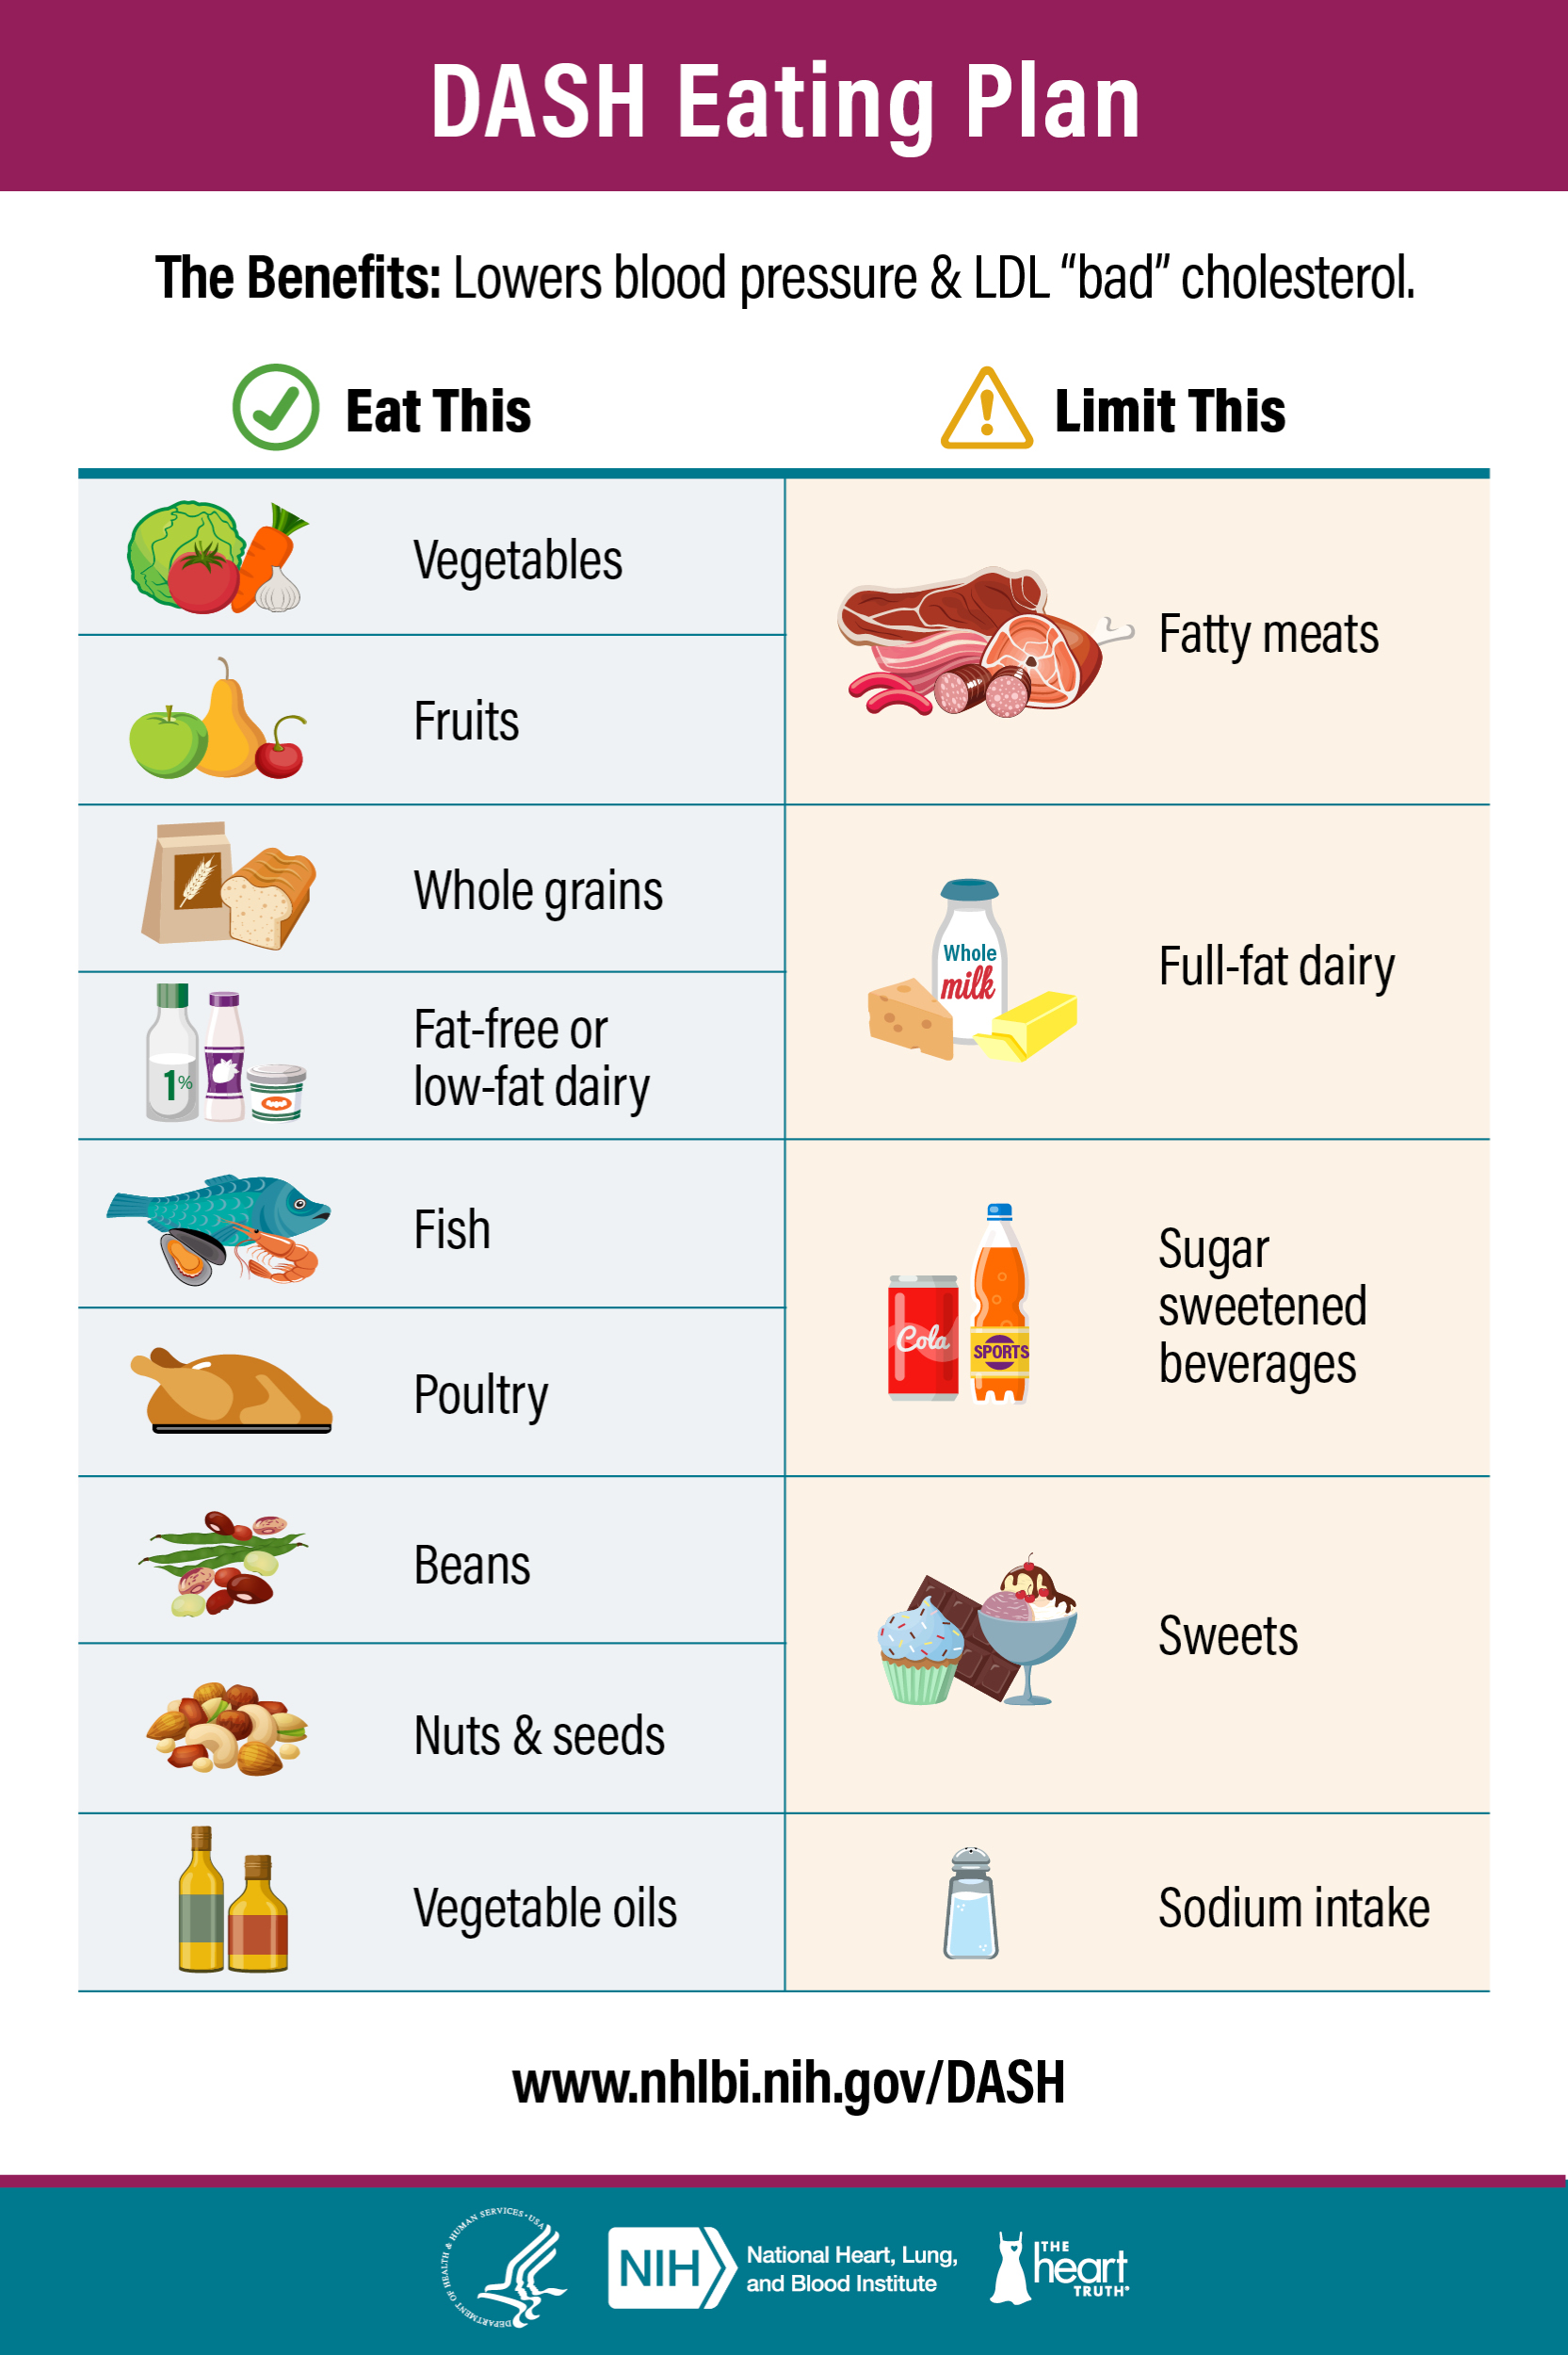

In [5]:
# 合并两个 DataFrame
df_daily_food = daily_nutrition_intake_summary.merge(df_food_user, on=['user_id', 'day', 'years'], how='left')
df_daily_food.columns

Index(['user_id', 'years', 'day', 'age_group', 'gender', 'grams_x', 'calorie',
       'protein', 'carb', 'sugar', 'fiber', 'saturated_fat', 'cholesterol',
       'folic_acid', 'vitamin_b12', 'vitamin_c', 'vitamin_d', 'calcium',
       'phosphorus', 'potassium', 'iron', 'sodium', 'age',
       'user_low_phosphorus', 'user_low_carb', 'weight', 'height',
       'under_weight', 'over_weight', 'user_low_calorie', 'user_high_calorie',
       'user_low_sodium', 'user_high_potassium', 'blood_pressure',
       'user_low_saturated_fat', 'user_low_cholesterol',
       'low_density_lipoprotein', 'blood_urea_nitrogen', 'user_low_protein',
       'user_high_protein', 'opioid_misuse', 'diabetes', 'user_low_sugar',
       'user_high_fiber', 'anemia', 'user_high_vitamin_b12',
       'user_high_folate_acid', 'user_high_iron', 'user_high_vitamin_c',
       'user_high_calcium', 'user_high_vitamin_d', 'osteoporosis', 'level',
       'b_calorie', 'b_carb', 'b_fiber', 'b_protein', 'b_saturated_fat',
       '

In [6]:
df_daily_food = df_daily_food.merge(df_food_code,on=['food_id','years'],how='left')
df_daily_food[df_daily_food['user_id']==21005][['day','eating_type','macro_health_score','micro_health_score','food_id','positive','negative']].sort_values(by='eating_type')

,day,eating_type,macro_health_score,micro_health_score,food_id,positive,negative
3,1.0,2.0,6,8,25230230,0,0
6,1.0,2.0,6,8,54403020,0,0
5,1.0,2.0,6,8,83110000,0,0
4,1.0,2.0,6,8,51301010,0,0
7,1.0,2.0,6,8,92541010,0,0
26,2.0,2.0,4,7,71401000,0,0
25,2.0,2.0,4,7,22600100,0,0
28,2.0,2.0,4,7,92410710,0,0
24,2.0,2.0,4,7,14010100,0,0
23,2.0,2.0,4,7,75117020,0,0


In [16]:
# 按 ['user_id', 'day', 'years'] 聚合分数
score_summary = df_daily_food.groupby(['user_id', 'day', 'years']).agg(
    total_positive_score=('positive', 'sum'),
    total_negative_score=('negative', 'sum')
).reset_index()
score_summary

,user_id,day,years,total_positive_score,total_negative_score
0,21005,1.0,304,0,0
1,21005,2.0,304,0,0
2,21009,1.0,304,0,0
3,21009,2.0,304,0,0
4,21010,1.0,304,0,0
...,...,...,...,...,...
33343,124792,2.0,1720,0,0
33344,124807,1.0,1720,0,0
33345,124810,1.0,1720,0,0
33346,124814,1.0,1720,0,0


In [ ]:

# 将分数写入 daily_nutrition_intake_summary
daily_nutrition_intake_summary = daily_nutrition_intake_summary.merge(score_summary, on=['user_id', 'day', 'years'], how='left')

# 查看结果
daily_nutrition_intake_summary[daily_nutrition_intake_summary['total_positive_score']>1]

In [8]:
len(daily_nutrition_intake_summary)

33348

# 4. Visualization

## 4.1 Macro and Micro 

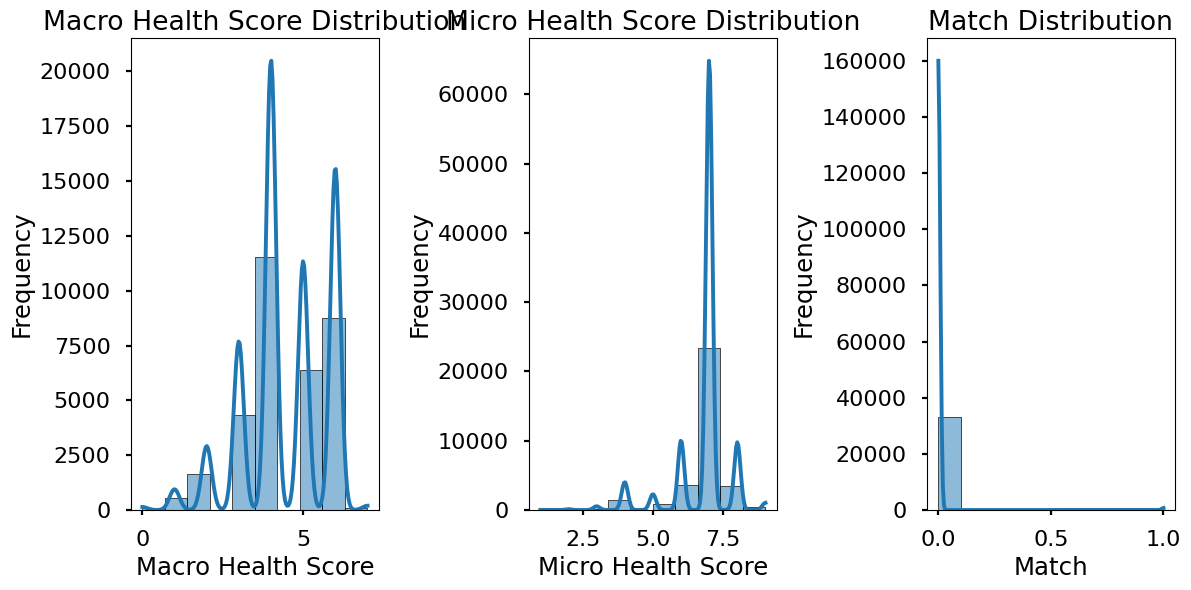

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置风格
plt.style.use('seaborn-v0_8-poster')

# 创建直方图
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(daily_nutrition_intake_summary['macro_health_score'], bins=10, kde=True)
plt.title('Macro Health Score Distribution')
plt.xlabel('Macro Health Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(daily_nutrition_intake_summary['micro_health_score'], bins=10, kde=True)
plt.title('Micro Health Score Distribution')
plt.xlabel('Micro Health Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(daily_nutrition_intake_summary['match'], bins=10, kde=True)
plt.title('Match Distribution')
plt.xlabel('Match')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4.2 Macro Nutrients 

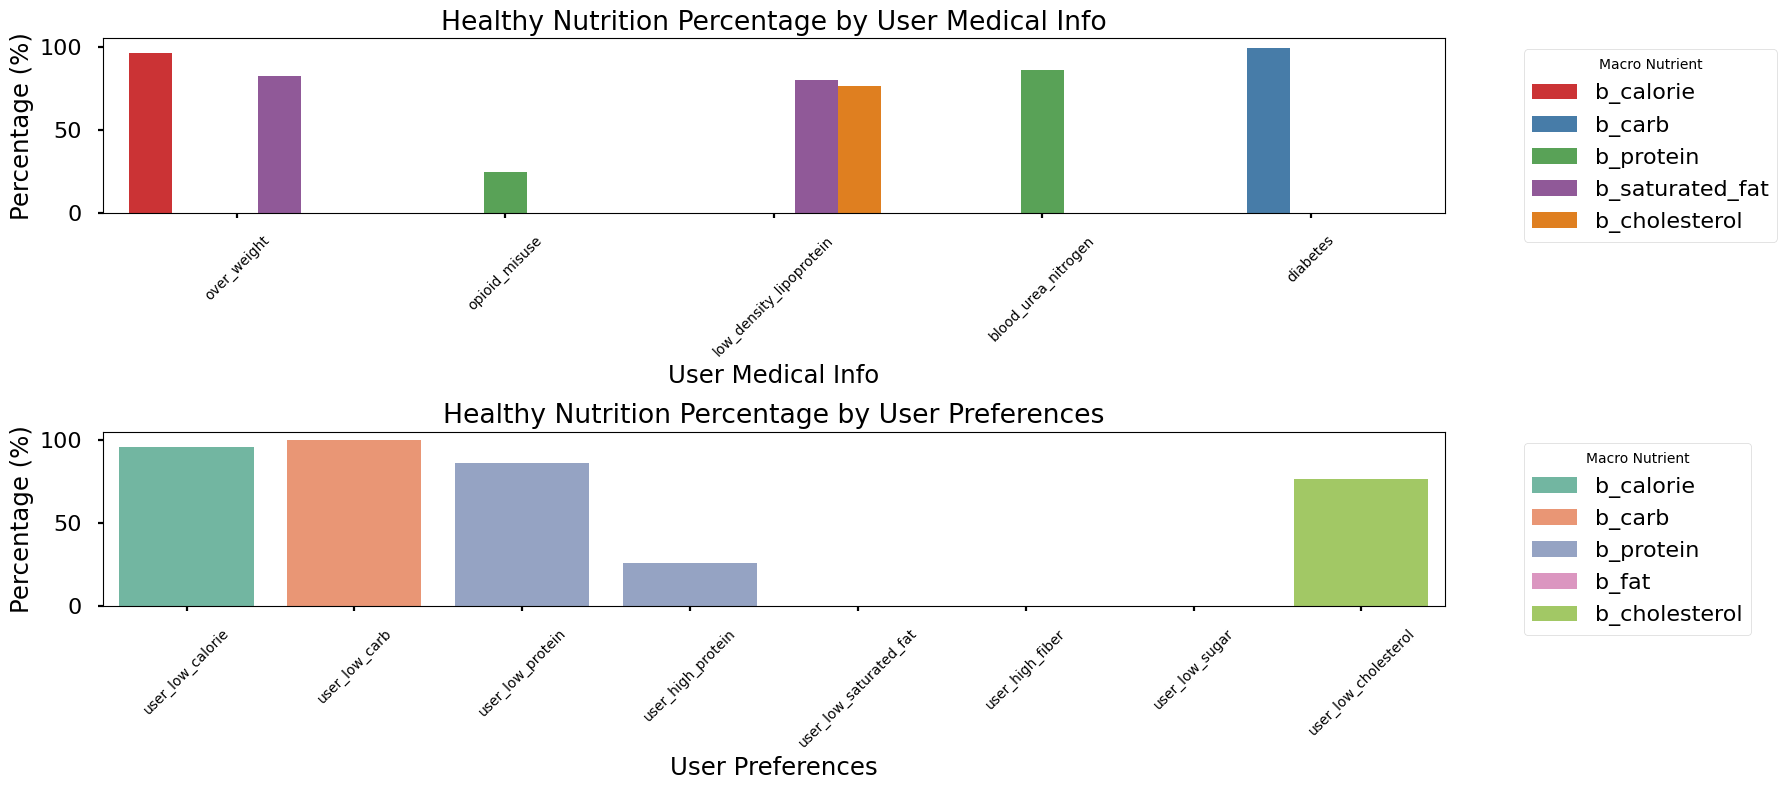

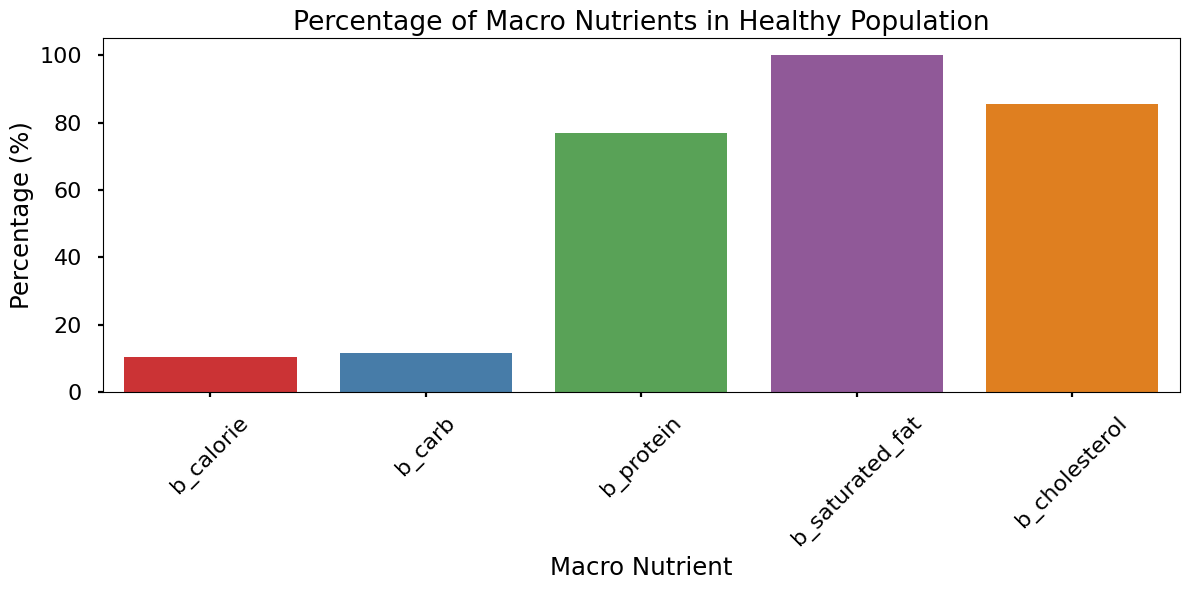

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.health_evaluate import medical_cols

# 定义 health_tags 列及其对应的目标营养指标
health_tags_to_nutrients = [
    ('over_weight', 'b_calorie'),
    ('over_weight', 'b_saturated_fat'), 
    ('over_weight','b_sugar'),
    ('opioid_misuse','b_sugar'),
    ('opioid_misuse','b_fiber'),
    ('low_density_lipoprotein','b_fiber'),
    ('low_density_lipoprotein','b_cholesterol'),
    ('low_density_lipoprotein', 'b_saturated_fat'), 
    ('blood_urea_nitrogen', 'b_protein'),
    ('opioid_misuse', 'b_protein'),
    ('diabetes', 'b_carb'),
    ('diabetes','b_sugar'),
  

]

# 定义 user_preferences 列及其对应的目标营养指标
user_preference_to_nutrients = [
    ('user_low_calorie', 'b_calorie'),
    ('user_low_carb', 'b_carb'),
    ('user_low_protein', 'b_protein'),
    ('user_high_protein', 'b_protein'),
    ('user_low_saturated_fat', 'b_saturated_fat'),
     ('user_high_fiber', 'b_fiber'),
    ('user_low_sugar','b_sugar'),
    ('user_low_cholesterol','b_cholesterol')
]

def calculate_tag_nutrient_percentage(tag_nutrient_pairs, tag_name_col):
    result = {}
    for tag, nutrient in tag_nutrient_pairs:
        key = (tag, nutrient)
        if key in result:
            continue
        total = (daily_nutrition_intake_summary[tag] == 1).sum()
        if total == 0:
            result[key] = 0.0
        else:
            target_nutrient_1 = ((daily_nutrition_intake_summary[tag] == 1) & 
                                (daily_nutrition_intake_summary[nutrient] == 1)).sum()
            result[key] = target_nutrient_1 / total * 100  # 转换为百分比

    result_df = pd.DataFrame(list(result.items()), columns=['Tag_Nutrient', 'Percentage'])
    result_df[[tag_name_col, 'Macro Nutrient']] = pd.DataFrame(result_df['Tag_Nutrient'].tolist(), index=result_df.index)
    return result_df

health_df = calculate_tag_nutrient_percentage(health_tags_to_nutrients, 'User Medical Info')
health_df['Type'] = 'User Medical Info'

preference_df = calculate_tag_nutrient_percentage(user_preference_to_nutrients, 'Preference Tag')
preference_df['Type'] = 'User Preference'

# 绘制两个子图
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharey=True)

# 绘制健康标签条形图
sns.barplot(x='User Medical Info', y='Percentage', hue='Macro Nutrient', data=health_df, 
            palette='Set1', ax=axes[0], hue_order=['b_calorie', 'b_carb',  'b_protein', 'b_saturated_fat', 'b_cholesterol'])
axes[0].set_title('Healthy Nutrition Percentage by User Medical Info')
axes[0].set_xlabel('User Medical Info')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Macro Nutrient', bbox_to_anchor=(1.05, 1), loc='upper left')

# 绘制用户偏好条形图
sns.barplot(x='Preference Tag', y='Percentage', hue='Macro Nutrient', data=preference_df, 
            palette='Set2', ax=axes[1], hue_order=['b_calorie', 'b_carb', 'b_protein', 'b_fat', 'b_cholesterol'])
axes[1].set_title('Healthy Nutrition Percentage by User Preferences')
axes[1].set_xlabel('User Preferences')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Macro Nutrient', bbox_to_anchor=(1.05, 1), loc='upper left')
# 旋转 x 轴标签并减小字体大小
for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=10)
plt.tight_layout()
plt.show()

#健康人群各macro营养素的百分比

macro_nutrition_cols = ['b_calorie', 'b_carb', 'b_protein', 'b_saturated_fat', 'b_cholesterol']

# 定义计算健康人群中各宏观营养素百分比的函数
def calculate_healthy_population_nutrition(df, medical_cols, macro_nutrition_cols):
    # 筛选出健康人群（所有 medical_cols 的值均为 0）
    healthy_population = df[df[medical_cols].eq(0).all(axis=1)]
    
    # 计算健康人群中每个宏观营养素的百分比
    result = {}
    for nutrient in macro_nutrition_cols:
        total = len(healthy_population)
        if total == 0:
            result[nutrient] = 0.0
        else:
            nutrient_count = healthy_population[nutrient].sum()
            result[nutrient] = nutrient_count / total * 100  # 转换为百分比
    
    return pd.DataFrame(result.items(), columns=['Macro Nutrient', 'Percentage'])

# 计算健康人群各宏观营养素的百分比
healthy_nutrition_df = calculate_healthy_population_nutrition(daily_nutrition_intake_summary, medical_cols, macro_nutrition_cols)

# 绘制条形图
plt.figure(figsize=(12, 6))
sns.barplot(x='Macro Nutrient', y='Percentage',hue='Macro Nutrient', data=healthy_nutrition_df, palette='Set1')

plt.title('Percentage of Macro Nutrients in Healthy Population')
plt.xlabel('Macro Nutrient')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.3 Micro Nutrients

                     Tag_Nutrient  Percentage User Medical Info  \
0      (blood_pressure, b_sodium)   68.248877    blood_pressure   
1            (diabetes, b_sodium)   72.688679          diabetes   
2       (opioid_misuse, b_sodium)   74.260753     opioid_misuse   
3   (blood_pressure, b_potassium)    7.015715    blood_pressure   
4                (anemia, b_iron)   14.000000            anemia   
5           (anemia, b_vitamin_c)   12.380952            anemia   
6          (anemia, b_folic_acid)    2.095238            anemia   
7         (anemia, b_vitamin_b12)   77.428571            anemia   
8     (osteoporosis, b_vitamin_c)   22.874807      osteoporosis   
9       (osteoporosis, b_calcium)    7.882535      osteoporosis   
10    (osteoporosis, b_vitamin_d)    0.000000      osteoporosis   

   Micro Nutrient               Type  
0        b_sodium  User Medical Info  
1        b_sodium  User Medical Info  
2        b_sodium  User Medical Info  
3     b_potassium  User Medical Info  


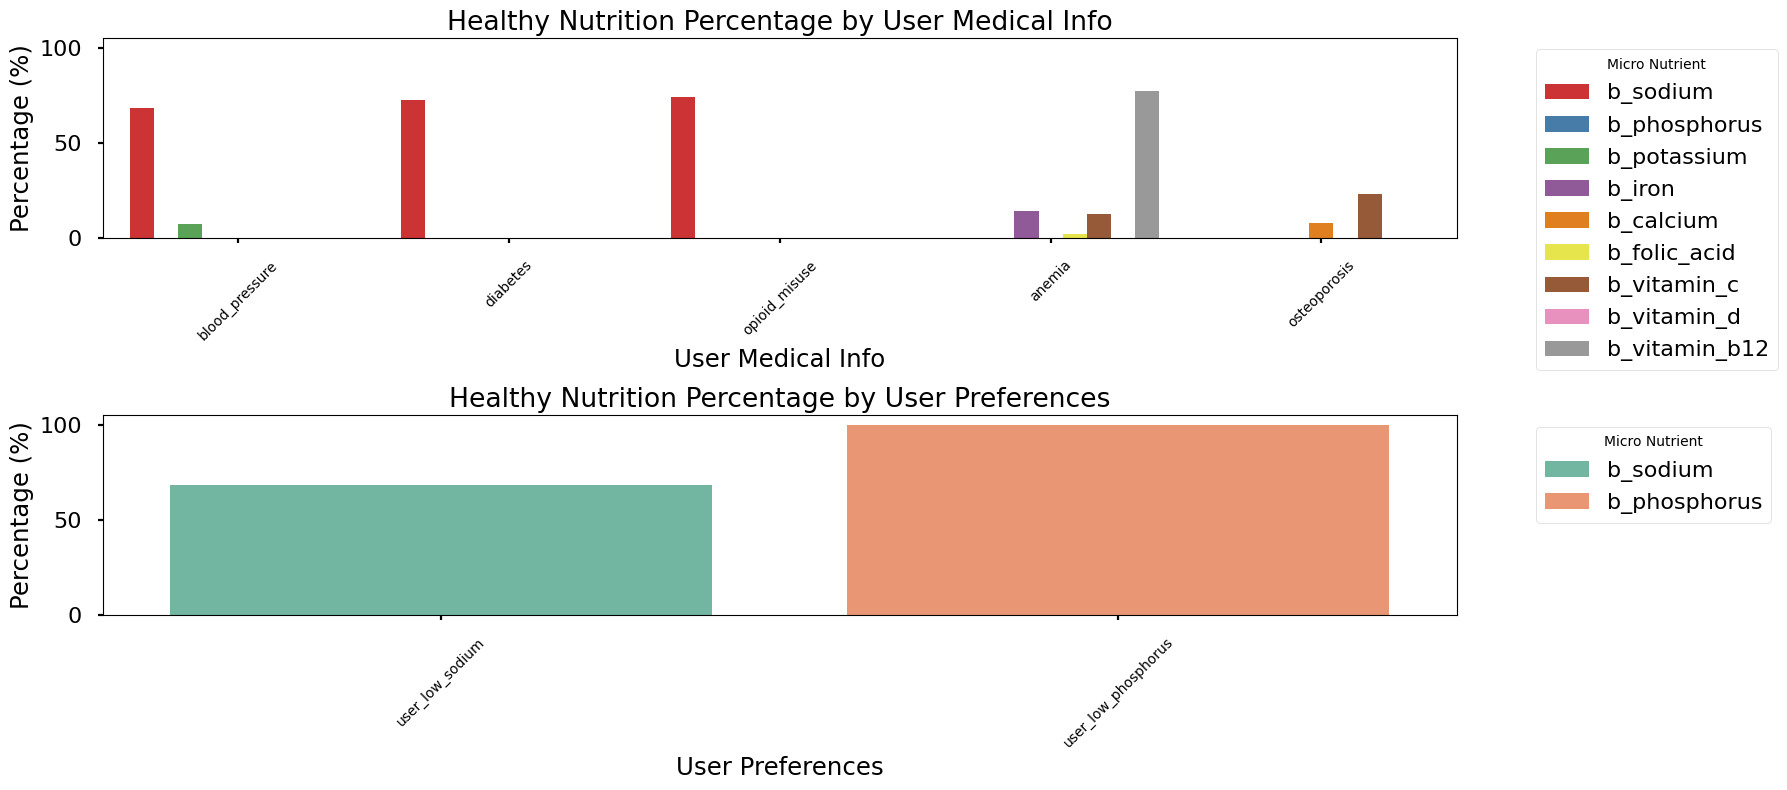

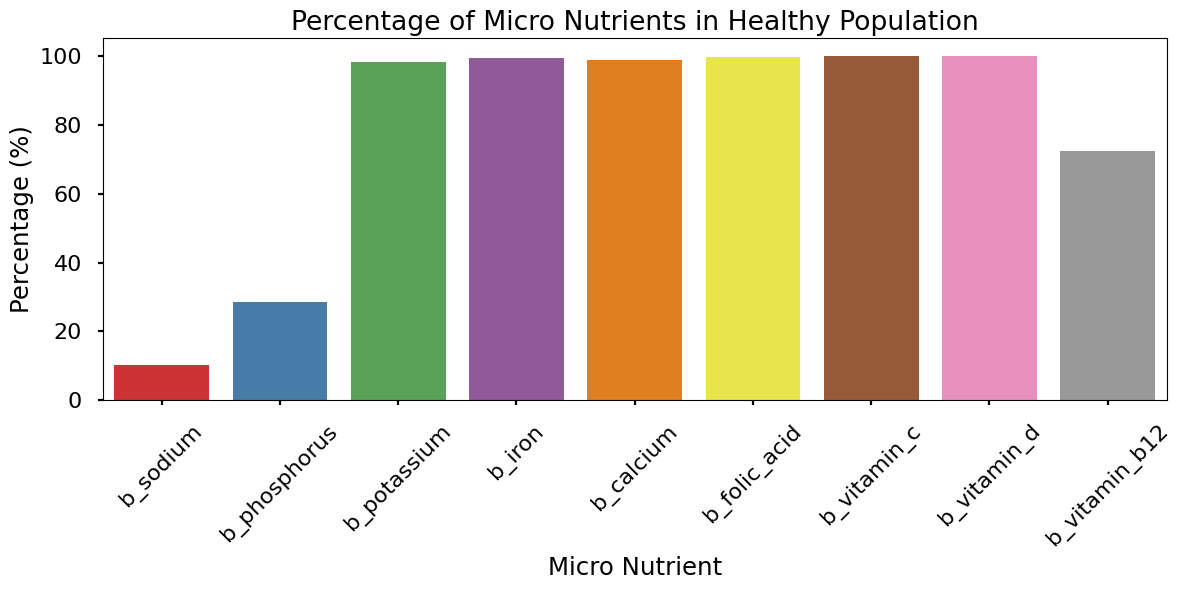

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 定义 health_tags 列及其对应的目标营养指标
health_tags_to_nutrients = [
    ('blood_pressure', 'b_sodium'),
    ('diabetes', 'b_sodium'), 
    ('opioid_misuse','b_sodium'),
    ('blood_pressure', 'b_potassium'),
    ('anemia','b_iron'),
    ('anemia', 'b_vitamin_c'), 
    ('anemia', 'b_folic_acid'),
    ('anemia','b_vitamin_b12'),
    ('osteoporosis', 'b_vitamin_c'),
    ('osteoporosis','b_calcium'),
    ('osteoporosis', 'b_vitamin_d'),   
]

# 定义 user_preferences 列及其对应的目标营养指标
user_preference_to_nutrients = [
    ('user_low_sodium', 'b_sodium'),
    ('user_low_phosphorus', 'b_phosphorus'),
]

def calculate_tag_nutrient_percentage(tag_nutrient_pairs, tag_name_col):
    result = {}
    for tag, nutrient in tag_nutrient_pairs:
        key = (tag, nutrient)
        if key in result:
            continue
        total = (daily_nutrition_intake_summary[tag] == 1).sum()
        if total == 0:
            result[key] = 0.0
        else:
            target_nutrient_1 = ((daily_nutrition_intake_summary[tag] == 1) & 
                                (daily_nutrition_intake_summary[nutrient] == 1)).sum()
            result[key] = target_nutrient_1 / total * 100  # 转换为百分比

    result_df = pd.DataFrame(list(result.items()), columns=['Tag_Nutrient', 'Percentage'])
    result_df[[tag_name_col, 'Micro Nutrient']] = pd.DataFrame(result_df['Tag_Nutrient'].tolist(), index=result_df.index)
    return result_df

health_df = calculate_tag_nutrient_percentage(health_tags_to_nutrients, 'User Medical Info')
health_df['Type'] = 'User Medical Info'
preference_df = calculate_tag_nutrient_percentage(user_preference_to_nutrients, 'Preference Tag')
preference_df['Type'] = 'User Preference'
print(health_df)
print(preference_df)
# 绘制两个子图
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharey=True)


micro_nutrition_cols = ['b_sodium','b_phosphorus','b_potassium','b_iron','b_calcium','b_folic_acid','b_vitamin_c','b_vitamin_d','b_vitamin_b12']
# 绘制健康标签条形图
sns.barplot(x='User Medical Info', y='Percentage', hue='Micro Nutrient', data=health_df, 
            palette='Set1', ax=axes[0], hue_order=micro_nutrition_cols)
axes[0].set_title('Healthy Nutrition Percentage by User Medical Info')
axes[0].set_xlabel('User Medical Info')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Micro Nutrient', bbox_to_anchor=(1.05, 1), loc='upper left')

# 绘制用户偏好条形图
sns.barplot(x='Preference Tag', y='Percentage', hue='Micro Nutrient', data=preference_df, 
            palette='Set2', ax=axes[1], hue_order=['b_sodium','b_phosphorus'])
axes[1].set_title('Healthy Nutrition Percentage by User Preferences')
axes[1].set_xlabel('User Preferences')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Micro Nutrient', bbox_to_anchor=(1.05, 1), loc='upper left')
# 旋转 x 轴标签并减小字体大小
for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=10)
plt.tight_layout()
plt.show()

#健康人群各micro营养素的百分比
# 定义健康相关的列和宏观营养素列



# 定义计算健康人群中各宏观营养素百分比的函数
def calculate_healthy_population_nutrition(df, medical_cols, micro_nutrition_cols):
    # 筛选出健康人群（所有 medical_cols 的值均为 0）
    healthy_population = df[df[medical_cols].eq(0).all(axis=1)]
    
    # 计算健康人群中每个宏观营养素的百分比
    result = {}
    for nutrient in micro_nutrition_cols:
        total = len(healthy_population)
        if total == 0:
            result[nutrient] = 0.0
        else:
            nutrient_count = healthy_population[nutrient].sum()
            result[nutrient] = nutrient_count / total * 100  # 转换为百分比
    
    return pd.DataFrame(result.items(), columns=['Micro Nutrient', 'Percentage'])

# 计算健康人群各宏观营养素的百分比
healthy_nutrition_df = calculate_healthy_population_nutrition(daily_nutrition_intake_summary, medical_cols, micro_nutrition_cols)

# 绘制条形图
plt.figure(figsize=(12, 6))
sns.barplot(x='Micro Nutrient', y='Percentage',hue='Micro Nutrient', data=healthy_nutrition_df, palette='Set1')

plt.title('Percentage of Micro Nutrients in Healthy Population')
plt.xlabel('Micro Nutrient')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
daily_nutrition_intake_summary.to_csv(f'{root_path}daily_nutrition.csv',index=False)

In [23]:
daily_nutrition_intake_summary.columns

Index(['SEQN', 'years', 'day', 'age_group', 'gender', 'grams', 'calorie',
       'protein', 'carb', 'sugar', 'fiber', 'saturated_fat', 'cholesterol',
       'folic_acid', 'vitamin_b12', 'vitamin_c', 'vitamin_d', 'calcium',
       'phosphorus', 'potassium', 'iron', 'sodium', 'age',
       'user_low_phosphorus', 'user_low_carb', 'weight', 'height',
       'user_high_calorie', 'user_low_calorie', 'under_weight', 'over_weight',
       'user_low_sodium', 'user_high_potassium', 'blood_pressure',
       'user_low_cholesterol', 'user_low_saturated_fat',
       'low_density_lipoprotein', 'user_low_protein', 'blood_urea_nitrogen',
       'opioid_misuse', 'user_high_protein', 'user_low_sugar',
       'user_high_fiber', 'diabetes', 'user_high_folate_acid',
       'user_high_vitamin_b12', 'anemia', 'user_high_iron', 'osteoporosis',
       'user_high_calcium', 'user_high_vitamin_d', 'user_high_vitamin_c',
       'level', 'b_calorie', 'b_carb', 'b_fiber', 'b_protein',
       'b_saturated_fat', 'b_sug

In [24]:
daily_nutrition_intake_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
SEQN,33348.0,64985.138239,29311.326108,21005.00,30426.000,69116.000,87853.75000,124814.00
years,33348.0,1036.212367,527.075657,304.00,304.000,1112.000,1516.00000,1720.00
day,33348.0,1.465095,0.498788,1.00,1.000,1.000,2.00000,2.00
age_group,33348.0,5.033765,1.614420,2.00,4.000,5.000,7.00000,7.00
gender,33348.0,1.508936,0.499928,1.00,1.000,2.000,2.00000,2.00
grams,33348.0,808.301229,1121.988858,0.31,100.000,265.000,1205.37750,14446.68
calorie,33348.0,823.417206,981.350389,0.00,153.000,399.000,1207.00000,9353.00
protein,33348.0,33.012987,40.037033,0.00,3.700,17.030,50.78000,407.31
carb,33348.0,96.657381,125.325084,0.00,13.960,41.655,138.93000,1413.69
sugar,33348.0,40.515393,66.701120,0.00,1.380,7.845,54.32250,789.29
